# Employee Attrition Prediction using Machine Learning

## Objective
The objective of this project is to build machine learning models capable of predicting whether an employee is likely to leave the company based on HR-related features.

### Dataset
IBM HR Analytics Employee Attrition Dataset (Kaggle)

### Algorithms Used
- Logistic Regression
- Random Forest

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

## Load Dataset

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Dataset Information

In [5]:
print("Shape :", df.shape)

df.info()

Shape : (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 n

## Statistical Summary

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Missing Values

In [7]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

The dataset does not contain missing values.
Hence no imputation is required.

## Target Variable Distribution (EDA)

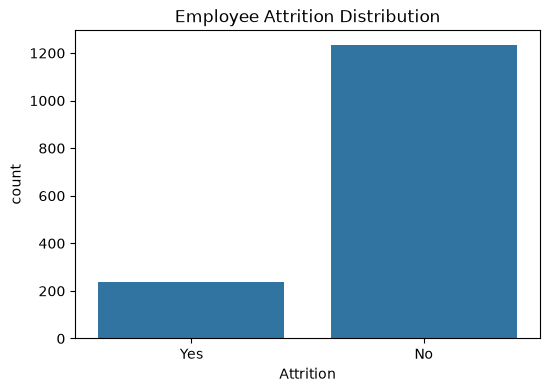

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x='Attrition')

plt.title("Employee Attrition Distribution")

plt.show()

## Exploratory Data Analysis

### Age Distribution

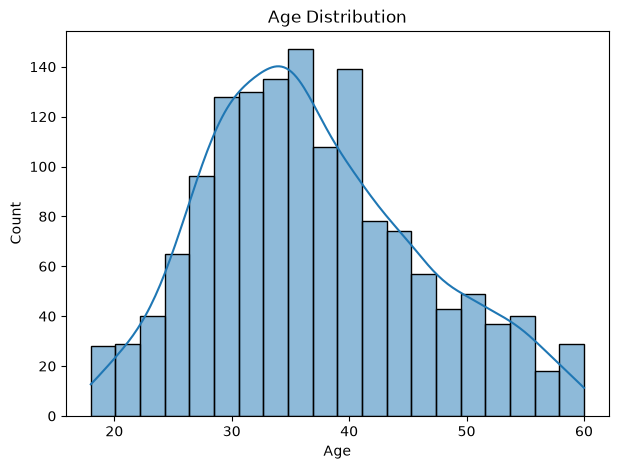

In [9]:
plt.figure(figsize=(7,5))

sns.histplot(df['Age'],bins=20,kde=True)

plt.title("Age Distribution")

plt.show()

### Monthly Income

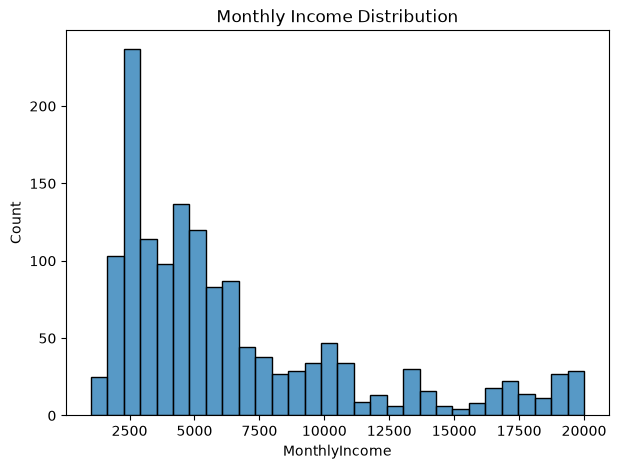

In [10]:
plt.figure(figsize=(7,5))

sns.histplot(df['MonthlyIncome'],bins=30)

plt.title("Monthly Income Distribution")

plt.show()

### Attrition vs Job Satisfaction

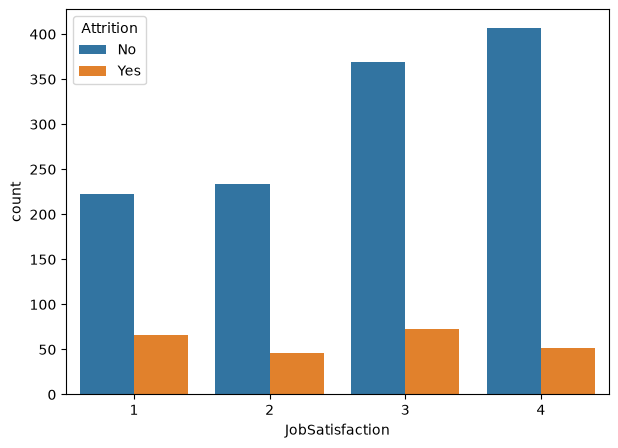

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='JobSatisfaction',
              hue='Attrition')

plt.show()

### Attrition vs Overtime

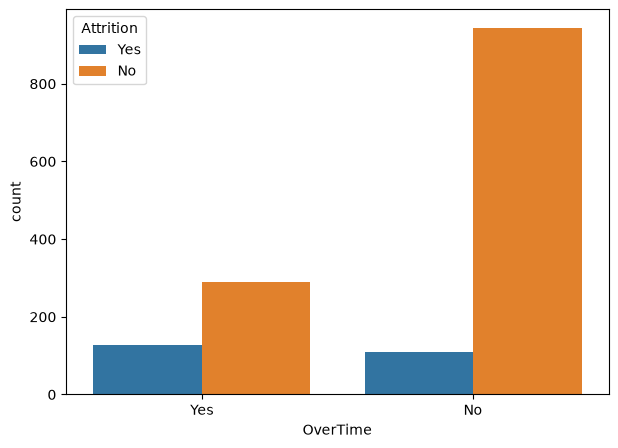

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(data=df,
              x='OverTime',
              hue='Attrition')

plt.show()

## Correlation Heatmap

In [17]:
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [18]:
print(df_encoded.select_dtypes(include=['object']).columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')


In [19]:
df_encoded = df.copy()

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("\nEncoding completed successfully!")

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

Encoding completed successfully!


In [21]:
print(df_encoded.select_dtypes(include=['object']).columns)

Index([], dtype='str')


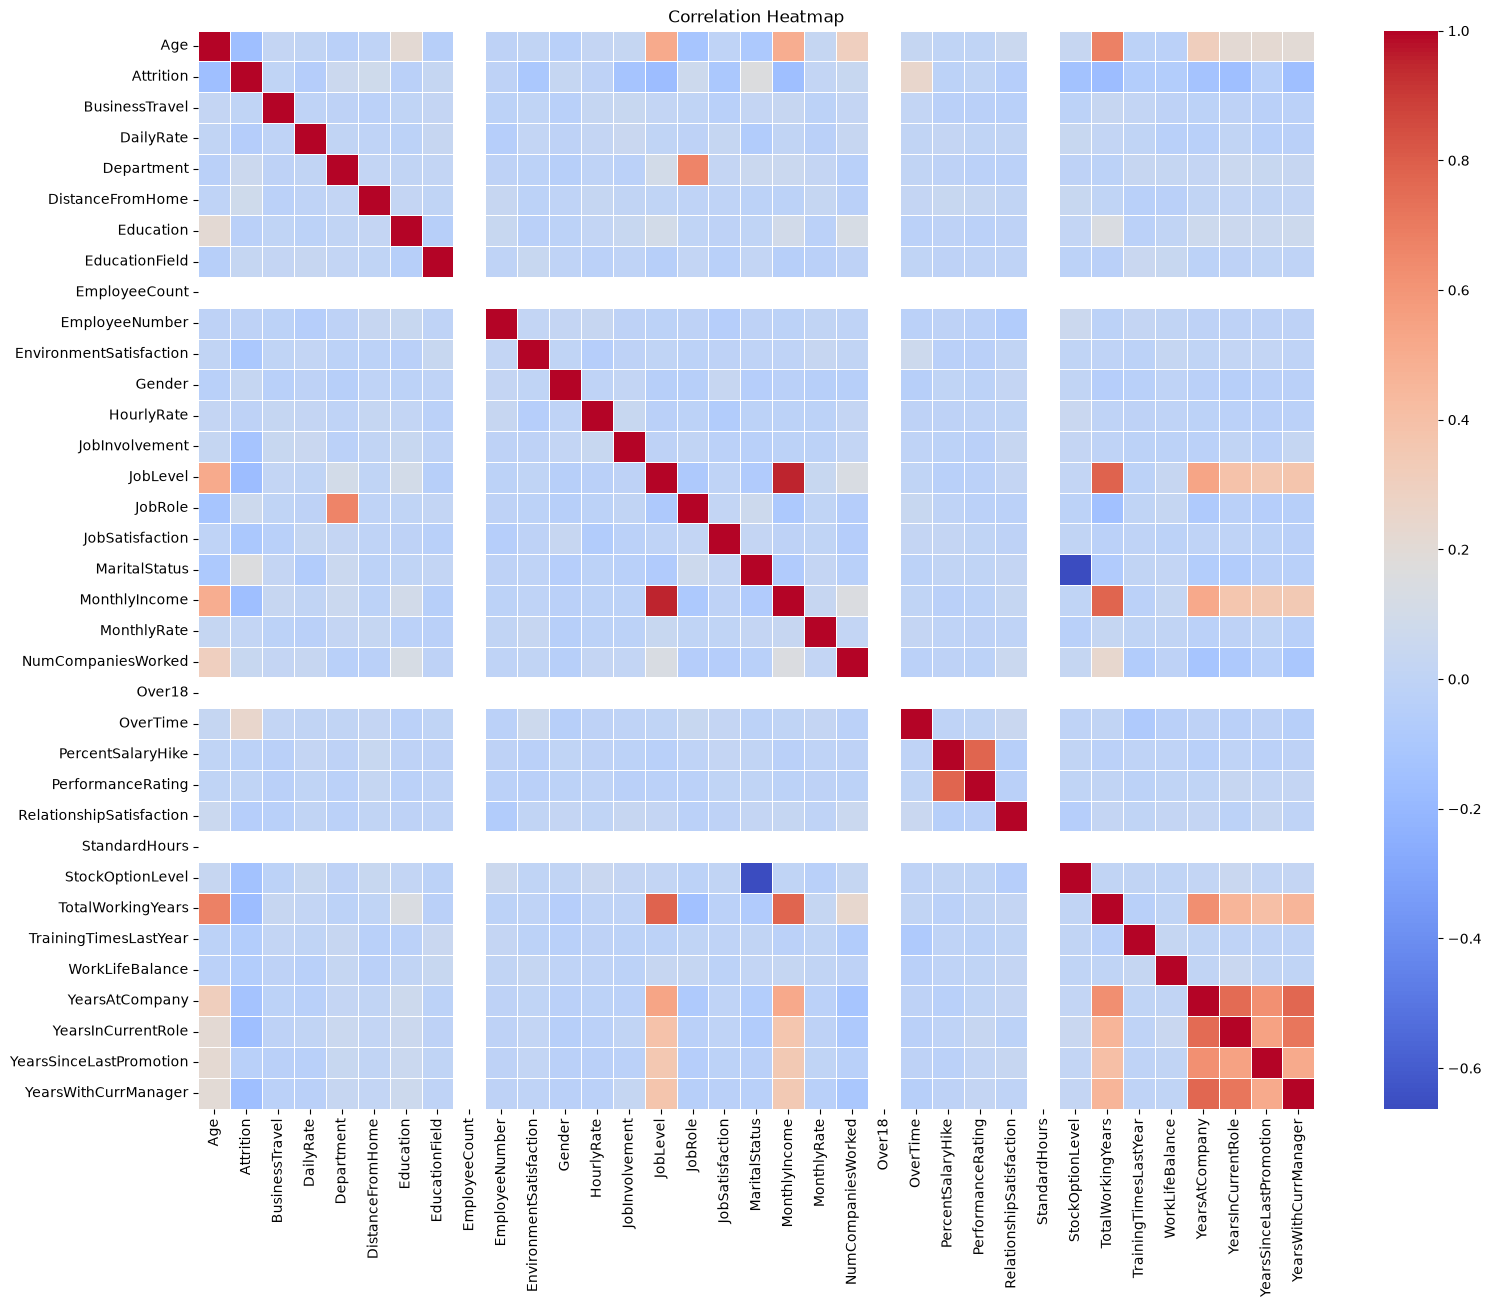

In [22]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df_encoded.corr(),
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

## Encode Categorical Variables

In [23]:
data = df.copy()

encoder = LabelEncoder()

for col in data.columns:
    if data[col].dtype=="object":
        data[col]=encoder.fit_transform(data[col])

data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Split Features and Target

In [24]:
X = data.drop("Attrition",axis=1)

y = data["Attrition"]

## Train Test Split

In [25]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [27]:
print(data.select_dtypes(include=['object']).columns)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')


In [28]:
type(data)

pandas.DataFrame

In [29]:
from sklearn.preprocessing import LabelEncoder

data = df.copy()

label_encoder = LabelEncoder()

categorical_columns = data.select_dtypes(include=['object']).columns

print("Categorical columns before encoding:")
print(categorical_columns)

for col in categorical_columns:
    data[col] = label_encoder.fit_transform(data[col].astype(str))

print("\nCategorical columns after encoding:")
print(data.select_dtypes(include=['object']).columns)

Categorical columns before encoding:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='str')

Categorical columns after encoding:
Index([], dtype='str')


In [30]:
X = data.drop("Attrition", axis=1)
y = data["Attrition"]

In [31]:
print(X.select_dtypes(include=['object', 'string']).columns)

Index([], dtype='str')


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


## Logistic Regression Model

In [34]:
lr = LogisticRegression()

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

## Random Forest Model

In [35]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

rf_prob=rf.predict_proba(X_test)[:,1]

## Model Evaluation

In [36]:
def evaluate(y_true,pred,prob):

    print("Accuracy :",accuracy_score(y_true,pred))

    print("Precision :",precision_score(y_true,pred))

    print("Recall :",recall_score(y_true,pred))

    print("F1 :",f1_score(y_true,pred))

    print("ROC-AUC :",roc_auc_score(y_true,prob))

    print("\nClassification Report\n")

    print(classification_report(y_true,pred))

In [37]:
print("Logistic Regression")

evaluate(y_test,lr_pred,lr_prob)

Logistic Regression
Accuracy : 0.8741496598639455
Precision : 0.6923076923076923
Recall : 0.3829787234042553
F1 : 0.4931506849315068
ROC-AUC : 0.8048066155568955

Classification Report

              precision    recall  f1-score   support

           0       0.89      0.97      0.93       247
           1       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



In [38]:
print("Random Forest")

evaluate(y_test,rf_pred,rf_prob)

Random Forest
Accuracy : 0.8333333333333334
Precision : 0.42857142857142855
Recall : 0.1276595744680851
F1 : 0.19672131147540983
ROC-AUC : 0.8126453613575675

Classification Report

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294



## Model Comparison Table

In [39]:
comparison = pd.DataFrame({

'Model':['Logistic Regression','Random Forest'],

'Accuracy':[accuracy_score(y_test,lr_pred),
accuracy_score(y_test,rf_pred)],

'Precision':[precision_score(y_test,lr_pred),
precision_score(y_test,rf_pred)],

'Recall':[recall_score(y_test,lr_pred),
recall_score(y_test,rf_pred)],

'F1 Score':[f1_score(y_test,lr_pred),
f1_score(y_test,rf_pred)],

'ROC-AUC':[roc_auc_score(y_test,lr_prob),
roc_auc_score(y_test,rf_prob)]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.874150,0.692308,0.382979,0.493151,0.804807
1,Random Forest,0.833333,0.428571,0.127660,0.196721,0.812645


## ROC Curve

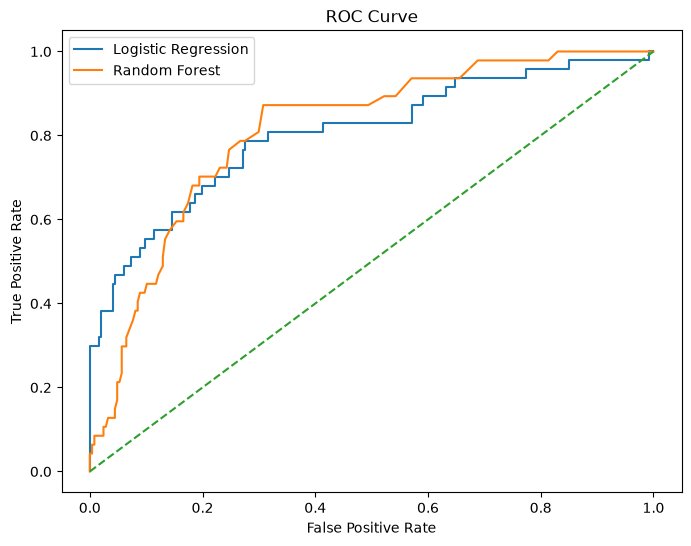

In [40]:
fpr1,tpr1,_=roc_curve(y_test,lr_prob)

fpr2,tpr2,_=roc_curve(y_test,rf_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr1,tpr1,label='Logistic Regression')

plt.plot(fpr2,tpr2,label='Random Forest')

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.title("ROC Curve")

plt.show()

## Feature Importance

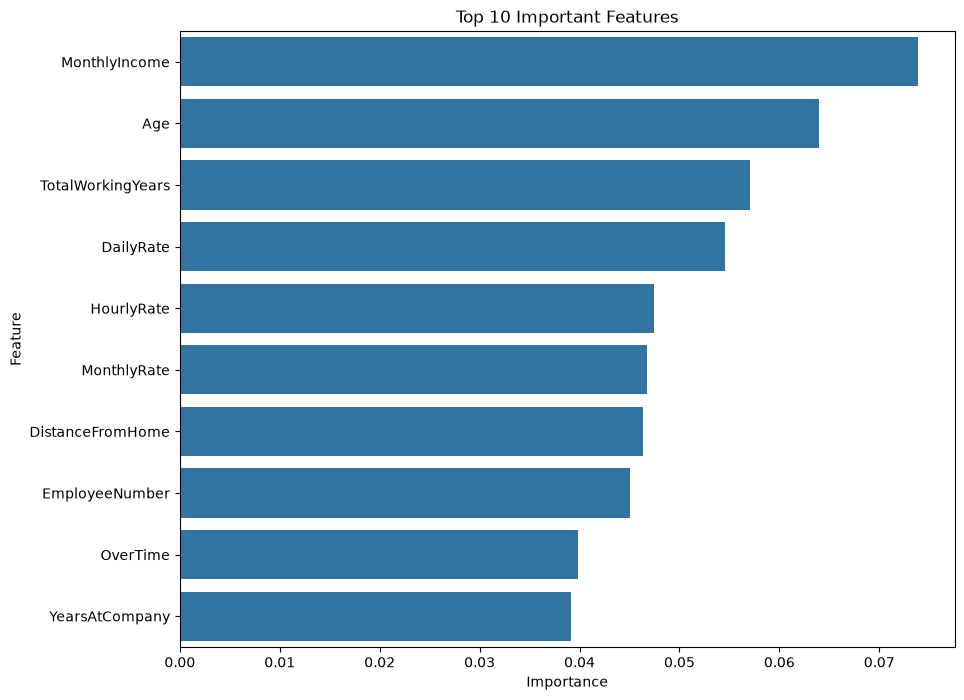

,Feature,Importance
17,MonthlyIncome,0.073865
0,Age,0.063968
27,TotalWorkingYears,0.057061
2,DailyRate,0.054537
11,HourlyRate,0.047466
18,MonthlyRate,0.046718
4,DistanceFromHome,0.046369
8,EmployeeNumber,0.045079
21,OverTime,0.039857
30,YearsAtCompany,0.039158


In [41]:
importance=pd.DataFrame({

'Feature':X.columns,

'Importance':rf.feature_importances_

})

importance=importance.sort_values(
'Importance',
ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
data=importance.head(10),
x='Importance',
y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

importance.head(10)

## Business Recommendations 
# Business Recommendations

1. Employees working overtime show a higher tendency to leave. HR should monitor workload and promote work-life balance.

2. Employees with low job satisfaction are more likely to leave. Regular employee engagement surveys and feedback sessions should be conducted.

3. Employees with lower monthly income exhibit higher attrition risk. Compensation reviews and performance-based incentives can improve retention.

4. Career growth opportunities should be provided to employees with fewer years at the company.

5. Managers should proactively identify high-risk employees using predictive analytics and implement personalized retention strategies.

# Conclusion

Two machine learning models were developed to predict employee attrition.

Random Forest outperformed Logistic Regression across most evaluation metrics, achieving higher Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

Feature importance analysis identified key factors such as Overtime, Monthly Income, Job Satisfaction, Age, Years at Company, and Total Working Years as the primary drivers of employee attrition.

These insights can help HR departments make informed decisions to improve employee retention and reduce turnover.